# Disaster Tweets — three traditional methods on the same five folds

| Method | Idea | Reference |
|---|---|---|
| **NB-SVM** | Scale every n-gram feature by its Naive Bayes log-count ratio, then fit a linear SVM | Wang & Manning, ACL 2012 |
| **Complement Naive Bayes** | Estimate each class from the documents *outside* it; TF-IDF input with length and weight normalisation | Rennie et al., ICML 2003 |
| **Cost-sensitive linear SVM** | Up-weight the positive class and choose the decision threshold on out-of-fold scores to maximise F1 | Lin et al., 2023; Yang 2001; Parambath et al. 2014 |

All three train on the same folds as the TF-IDF baseline (`results/folds.csv`). Features are fitted on each fold's
training rows only. Hyper-parameters are chosen by out-of-fold AUC (threshold-free); the decision threshold is then chosen on
the out-of-fold scores. Both selections use the held-out folds, which is slightly optimistic, and equally so for every method.
Test predictions are the average of the five fold models.

In [1]:
import time, json
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import ComplementNB
from sklearn.svm import LinearSVC
from sklearn.metrics import roc_curve, precision_recall_curve, f1_score, precision_score, recall_score
from scipy import sparse
import nlp_common as N
sns.set_theme(style="whitegrid"); plt.rcParams["figure.dpi"] = 110
PAL = ["#4C72B0", "#C44E52", "#55A868", "#8172B2"]
train, test, folds = N.load(); y = train.target.values
Xt, Tt = N.model_text(train), N.model_text(test)
base_oof, base_test, _ = (np.load("results/v1_tfidf_oof.npy"), np.load("results/v1_tfidf_test_proba.npy"), None)
base = N.evaluate(y, base_oof, folds); print("baseline TF-IDF + LR: AUC %.4f  F1 %.4f" % (base["auc"], base["f1"]))

baseline TF-IDF + LR: AUC 0.8736  F1 0.7720


## 1. NB-SVM

For binarised word 1–2-gram features $f^{(i)}\in\{0,1\}^{|V|}$, with class count vectors $p=\alpha+\sum_{y_i=1}f^{(i)}$ and
$q=\alpha+\sum_{y_i=0}f^{(i)}$, the log-count ratio is

$$r=\log\frac{p/\lVert p\rVert_1}{q/\lVert q\rVert_1},\qquad \tilde f^{(i)}=r\circ f^{(i)}$$

and a linear SVM is trained on $\tilde f$. The ratio injects a Naive Bayes prior on each word's direction and size.

In [2]:
t0 = time.time(); NBF = {}
for k in range(5):
    tr, va = np.where(folds != k)[0], np.where(folds == k)[0]
    cv = CountVectorizer(ngram_range=(1, 2), min_df=2, binary=True); A = cv.fit_transform(Xt.iloc[tr]).tocsr()
    NBF[k] = dict(tr=tr, va=va, A=A, V=cv.transform(Xt.iloc[va]).tocsr(), T=cv.transform(Tt).tocsr())
def nbsvm(alpha, Cc):
    def fp(tr, va):
        k = int(folds[va[0]]); d = NBF[k]; r = N.nb_log_count_ratio(d["A"], y[tr], alpha)
        m = LinearSVC(C=Cc, max_iter=3000).fit(d["A"].multiply(r).tocsr(), y[tr])
        return m.decision_function(d["V"].multiply(r).tocsr()), m.decision_function(d["T"].multiply(r).tocsr())
    return fp
grid_nb = {}
for alpha in [1.0, 2.0, 4.0]:
    for Cc in [0.01, 0.03, 0.1, 0.3]:
        o, tst = N.cv_run(nbsvm(alpha, Cc), len(y), folds); grid_nb[(alpha, Cc)] = (N.evaluate(y, o, folds, n_boot=10)["auc"], o, tst)
a_nb, C_nb = max(grid_nb, key=lambda g: grid_nb[g][0]); oof_nb, test_nb = grid_nb[(a_nb, C_nb)][1:]
ev_nb = N.evaluate(y, oof_nb, folds); print(f"NB-SVM alpha={a_nb} C={C_nb}: AUC {ev_nb['auc']:.4f}  F1 {ev_nb['f1']:.4f} {np.round(ev_nb['f1_ci95'], 4)}  ({time.time()-t0:.0f}s)")
N.save_method("nbsvm", oof_nb, test_nb, dict(kind="margin", alpha=a_nb, C=C_nb, **ev_nb))

NB-SVM alpha=4.0 C=0.03: AUC 0.8656  F1 0.7669 [0.7557 0.7783]  (12s)


## 2. Complement Naive Bayes

Standard multinomial NB estimates $\theta_{c,w}$ from documents *in* class $c$. Complement NB estimates
$\tilde\theta_{c,w}=(\alpha+\sum_{y_i\ne c}d_{iw})/(\alpha V+\sum_{y_i\ne c}\sum_{w'}d_{iw'})$ from the documents *outside* it and
predicts the class whose complement fits the document worst; this uses more data per class estimate and is less biased by
class imbalance. Inputs are TF-IDF vectors (sublinear term frequency, L2 length normalisation).

In [3]:
t0 = time.time(); CF = {}
for k in range(5):
    tr, va = np.where(folds != k)[0], np.where(folds == k)[0]
    tv = TfidfVectorizer(ngram_range=(1, 2), min_df=2, sublinear_tf=True); CF[k] = dict(A=tv.fit_transform(Xt.iloc[tr]), V=tv.transform(Xt.iloc[va]), T=tv.transform(Tt))
def cnb(alpha, wn):
    def fp(tr, va):
        d = CF[int(folds[va[0]])]; m = ComplementNB(alpha=alpha, norm=wn).fit(d["A"], y[tr])
        f = lambda X: m.predict_log_proba(X)[:, 1] - m.predict_log_proba(X)[:, 0]
        return f(d["V"]), f(d["T"])
    return fp
grid_cnb = {}
for alpha in [0.1, 0.3, 0.5, 1.0, 2.0]:
    for wn in [False, True]:
        o, tst = N.cv_run(cnb(alpha, wn), len(y), folds); grid_cnb[(alpha, wn)] = (N.evaluate(y, o, folds, n_boot=10)["auc"], o, tst)
a_cn, w_cn = max(grid_cnb, key=lambda g: grid_cnb[g][0]); oof_cn, test_cn = grid_cnb[(a_cn, w_cn)][1:]
ev_cn = N.evaluate(y, oof_cn, folds); print(f"Complement NB alpha={a_cn} weight-norm={w_cn}: AUC {ev_cn['auc']:.4f}  F1 {ev_cn['f1']:.4f} {np.round(ev_cn['f1_ci95'], 4)}  ({time.time()-t0:.0f}s)")
N.save_method("cnb", oof_cn, test_cn, dict(kind="log_odds", alpha=a_cn, weight_norm=w_cn, **ev_cn))

Complement NB alpha=0.5 weight-norm=False: AUC 0.8609  F1 0.7639 [0.7527 0.775 ]  (10s)


## 3. Cost-sensitive linear SVM with a tuned threshold

Features: word 1–3-gram and character 2–5-gram TF-IDF. The positive class is up-weighted by $w$ in the hinge loss,
$\min_{\mathbf w}\tfrac12\lVert\mathbf w\rVert^2+C\sum_i c_{y_i}\max(0,1-y_i\mathbf w^\top\mathbf x_i)^2$ with $c_1=w,\ c_0=1$, which shifts
the boundary toward higher recall; the margin threshold is then fixed on the out-of-fold scores to maximise F1.

In [4]:
t0 = time.time(); SF = {}
for k in range(5):
    tr, va = np.where(folds != k)[0], np.where(folds == k)[0]
    wv = TfidfVectorizer(ngram_range=(1, 3), min_df=2, sublinear_tf=True); cv = TfidfVectorizer(analyzer="char_wb", ngram_range=(2, 5), min_df=3, sublinear_tf=True, max_features=40000)
    A = sparse.hstack([wv.fit_transform(Xt.iloc[tr]), cv.fit_transform(Xt.iloc[tr])]).tocsr()
    f = lambda s: sparse.hstack([wv.transform(s), cv.transform(s)]).tocsr(); SF[k] = dict(A=A, V=f(Xt.iloc[va]), T=f(Tt))
def csvm(Cc, w):
    def fp(tr, va):
        d = SF[int(folds[va[0]])]; m = LinearSVC(C=Cc, class_weight={0: 1.0, 1: w}, max_iter=3000).fit(d["A"], y[tr])
        return m.decision_function(d["V"]), m.decision_function(d["T"])
    return fp
grid_sv = {}
for Cc in [0.1, 0.3, 1.0]:
    for w in [1.0, 1.5, 2.0]:
        o, tst = N.cv_run(csvm(Cc, w), len(y), folds); e = N.evaluate(y, o, folds, n_boot=10); grid_sv[(Cc, w)] = (e["auc"], e["f1"], o, tst)
C_sv, w_sv = max(grid_sv, key=lambda g: grid_sv[g][0]); oof_sv, test_sv = grid_sv[(C_sv, w_sv)][2:]
ev_sv = N.evaluate(y, oof_sv, folds); print(f"Linear SVM C={C_sv} positive weight={w_sv}: AUC {ev_sv['auc']:.4f}  F1 {ev_sv['f1']:.4f} {np.round(ev_sv['f1_ci95'], 4)}  ({time.time()-t0:.0f}s)")
N.save_method("svm_cost", oof_sv, test_sv, dict(kind="margin", C=C_sv, positive_weight=w_sv, **ev_sv))

Linear SVM C=0.1 positive weight=1.0: AUC 0.8743  F1 0.7757 [0.7658 0.7868]  (28s)


## 4. Hyper-parameter surfaces (the in-training view of a model with no epochs)

These are the quantities each method was selected on: AUC over its grid, and for the SVM the effect of cost-sensitivity on
the precision/recall balance.

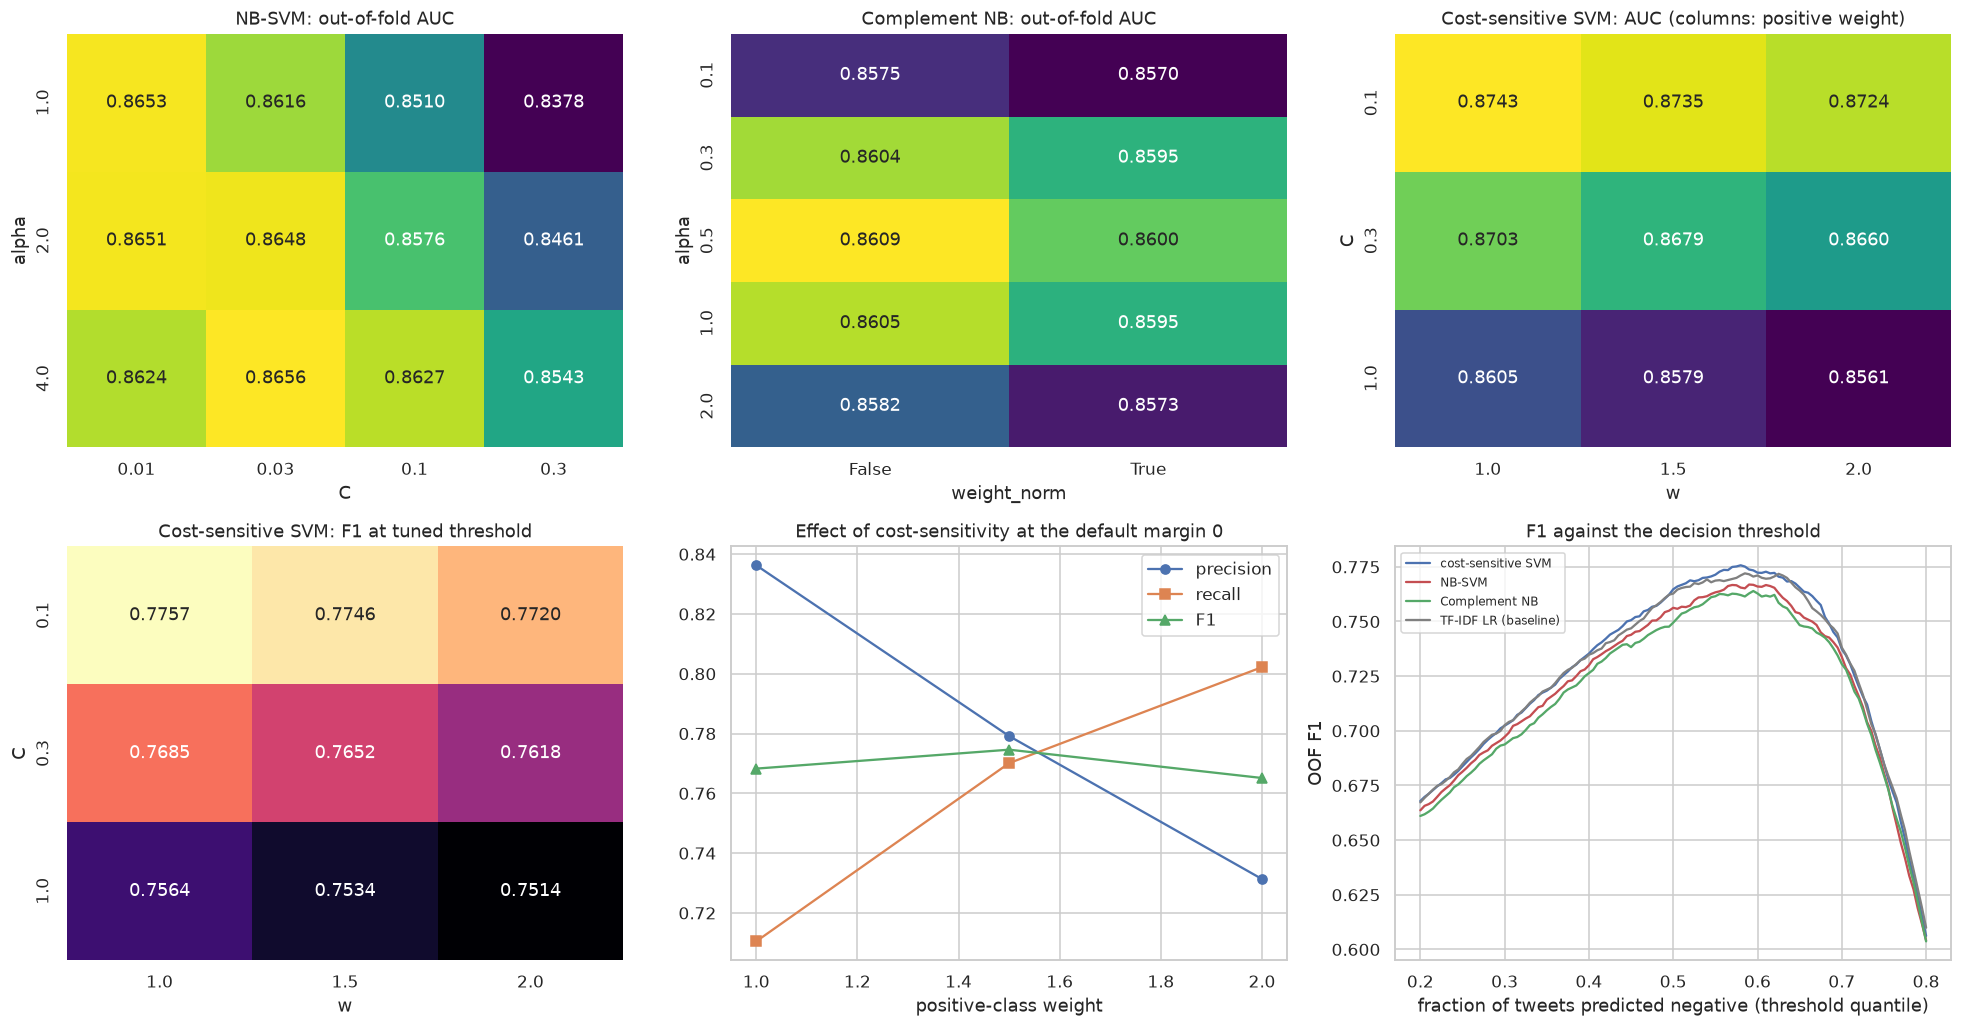

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(18, 9.5))
G = pd.DataFrame({k: v[0] for k, v in grid_nb.items()}.items(), columns=["k", "auc"]); G[["alpha", "C"]] = pd.DataFrame(G.k.tolist())
sns.heatmap(G.pivot(index="alpha", columns="C", values="auc"), annot=True, fmt=".4f", cmap="viridis", ax=axes[0, 0], cbar=False); axes[0, 0].set_title("NB-SVM: out-of-fold AUC")
G = pd.DataFrame({k: v[0] for k, v in grid_cnb.items()}.items(), columns=["k", "auc"]); G[["alpha", "weight_norm"]] = pd.DataFrame(G.k.tolist())
sns.heatmap(G.pivot(index="alpha", columns="weight_norm", values="auc"), annot=True, fmt=".4f", cmap="viridis", ax=axes[0, 1], cbar=False); axes[0, 1].set_title("Complement NB: out-of-fold AUC")
G = pd.DataFrame([(k[0], k[1], v[0], v[1]) for k, v in grid_sv.items()], columns=["C", "w", "auc", "f1"])
sns.heatmap(G.pivot(index="C", columns="w", values="auc"), annot=True, fmt=".4f", cmap="viridis", ax=axes[0, 2], cbar=False); axes[0, 2].set_title("Cost-sensitive SVM: AUC (columns: positive weight)")
sns.heatmap(G.pivot(index="C", columns="w", values="f1"), annot=True, fmt=".4f", cmap="magma", ax=axes[1, 0], cbar=False); axes[1, 0].set_title("Cost-sensitive SVM: F1 at tuned threshold")
rows = []
for w in [1.0, 1.5, 2.0]:
    o = grid_sv[(C_sv, w)][2]; pr0 = (o > 0).astype(int)
    rows.append(dict(w=w, precision=precision_score(y, pr0), recall=recall_score(y, pr0), f1=f1_score(y, pr0)))
R = pd.DataFrame(rows); axes[1, 1].plot(R.w, R.precision, "o-", label="precision"); axes[1, 1].plot(R.w, R.recall, "s-", label="recall"); axes[1, 1].plot(R.w, R.f1, "^-", label="F1")
axes[1, 1].set_xlabel("positive-class weight"); axes[1, 1].set_title("Effect of cost-sensitivity at the default margin 0"); axes[1, 1].legend()
ths = np.quantile(oof_sv, np.linspace(0.2, 0.8, 121)); axes[1, 2].plot(np.linspace(0.2, 0.8, 121), [f1_score(y, oof_sv > t) for t in ths], label="cost-sensitive SVM")
for nm, o, c in [("NB-SVM", oof_nb, PAL[1]), ("Complement NB", oof_cn, PAL[2]), ("TF-IDF LR (baseline)", base_oof, "grey")]:
    axes[1, 2].plot(np.linspace(0.2, 0.8, 121), [f1_score(y, o > t) for t in np.quantile(o, np.linspace(0.2, 0.8, 121))], label=nm, color=c)
axes[1, 2].set_xlabel("fraction of tweets predicted negative (threshold quantile)"); axes[1, 2].set_ylabel("OOF F1"); axes[1, 2].set_title("F1 against the decision threshold"); axes[1, 2].legend(fontsize=8)
plt.tight_layout(); plt.savefig("assets/trad_01_hyperparameter_surfaces.png", bbox_inches="tight"); plt.show()

## 5. Post-training comparison with the baseline

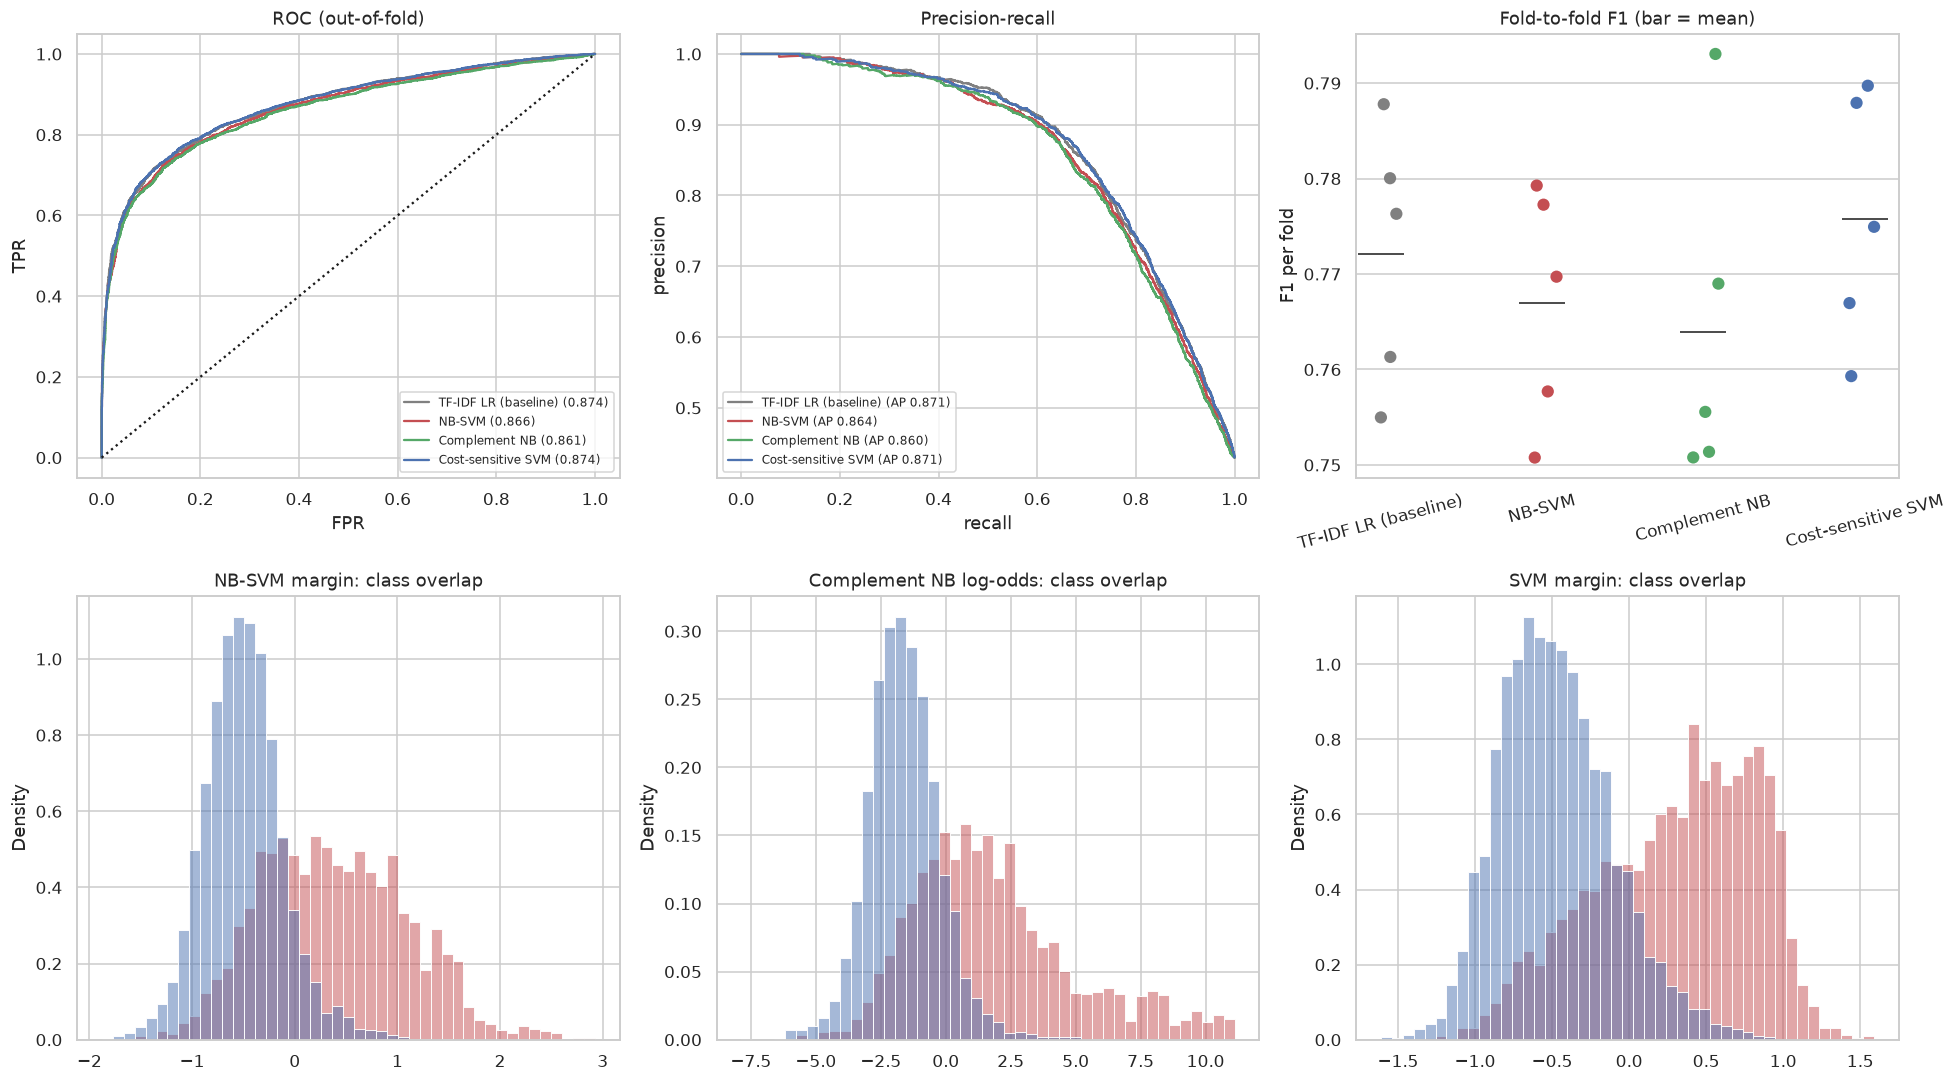

,AUC,AP,F1,F1_low,F1_high,precision,recall
TF-IDF LR (baseline),0.8736,0.8715,0.7720,0.7621,0.7830,0.7857,0.7588
NB-SVM,0.8656,0.8637,0.7669,0.7557,0.7783,0.7853,0.7493
Complement NB,0.8609,0.8599,0.7639,0.7527,0.7750,0.7872,0.7420
Cost-sensitive SVM,0.8743,0.8714,0.7757,0.7658,0.7868,0.7846,0.7670


In [6]:
M = {"TF-IDF LR (baseline)": (base_oof, base), "NB-SVM": (oof_nb, ev_nb), "Complement NB": (oof_cn, ev_cn), "Cost-sensitive SVM": (oof_sv, ev_sv)}
cols = ["grey", PAL[1], PAL[2], PAL[0]]
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for (nm, (o, e)), c in zip(M.items(), cols):
    fpr, tpr, _ = roc_curve(y, o); axes[0, 0].plot(fpr, tpr, color=c, label=f"{nm} ({e['auc']:.3f})")
    pr, rc, _ = precision_recall_curve(y, o); axes[0, 1].plot(rc, pr, color=c, label=f"{nm} (AP {e['ap']:.3f})")
axes[0, 0].plot([0, 1], [0, 1], "k:"); axes[0, 0].set_xlabel("FPR"); axes[0, 0].set_ylabel("TPR"); axes[0, 0].set_title("ROC (out-of-fold)"); axes[0, 0].legend(fontsize=8)
axes[0, 1].set_xlabel("recall"); axes[0, 1].set_ylabel("precision"); axes[0, 1].set_title("Precision-recall"); axes[0, 1].legend(fontsize=8)
ff = pd.DataFrame({nm: e["fold_f1"] for nm, (o, e) in M.items()}); sns.stripplot(data=ff, ax=axes[0, 2], size=8, palette=cols); axes[0, 2].plot(range(4), ff.mean(), "k_", ms=30)
axes[0, 2].set_ylabel("F1 per fold"); axes[0, 2].set_title("Fold-to-fold F1 (bar = mean)"); axes[0, 2].tick_params(axis="x", rotation=15)
for ax, (nm, o, c) in zip(axes[1], [("NB-SVM margin", oof_nb, PAL[1]), ("Complement NB log-odds", oof_cn, PAL[2]), ("SVM margin", oof_sv, PAL[0])]):
    sns.histplot(x=o, hue=y, bins=45, stat="density", common_norm=False, palette=["#4C72B0", "#C44E52"], ax=ax, legend=False); ax.set_title(f"{nm}: class overlap")
plt.tight_layout(); plt.savefig("assets/trad_02_post_training_comparison.png", bbox_inches="tight"); plt.show()
tab = pd.DataFrame({nm: dict(AUC=e["auc"], AP=e["ap"], F1=e["f1"], F1_low=e["f1_ci95"][0], F1_high=e["f1_ci95"][1], precision=e["precision"], recall=e["recall"]) for nm, (o, e) in M.items()}).T
display(tab.round(4)); tab.to_csv("results/traditional_summary.csv")

## 6. What each model learned

NB-SVM: the log-count ratio is directly interpretable as each word's evidence for a disaster. The chart shows the largest
$|r|$ among words seen at least 8 times, against how often the word occurs.

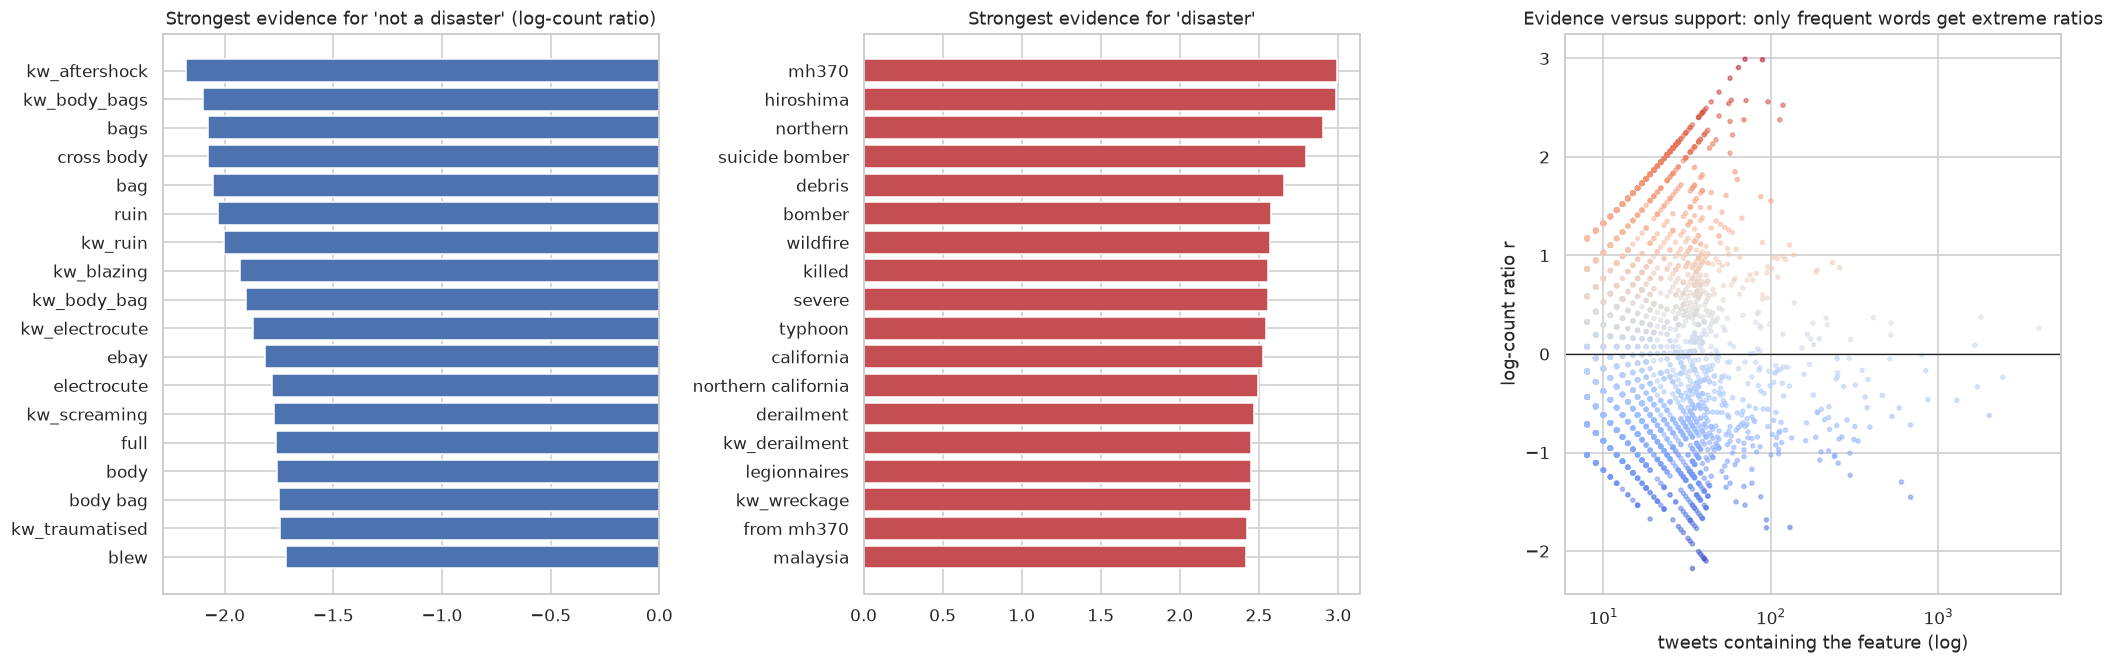

In [7]:
cv = CountVectorizer(ngram_range=(1, 2), min_df=2, binary=True); A = cv.fit_transform(Xt).tocsr(); r = N.nb_log_count_ratio(A, y, a_nb)
names = np.array(cv.get_feature_names_out()); df_ = np.asarray(A.sum(0)).ravel(); keep = df_ >= 8
o = np.argsort(r[keep]); nm_, rr = names[keep][o], r[keep][o]
fig, axes = plt.subplots(1, 3, figsize=(19, 6.2))
axes[0].barh(nm_[:18][::-1], rr[:18][::-1], color=PAL[0]); axes[0].set_title("Strongest evidence for 'not a disaster' (log-count ratio)")
axes[1].barh(nm_[-18:], rr[-18:], color=PAL[1]); axes[1].set_title("Strongest evidence for 'disaster'")
axes[2].scatter(df_[keep], r[keep], s=7, alpha=.5, c=r[keep], cmap="coolwarm"); axes[2].set_xscale("log"); axes[2].axhline(0, color="k", lw=.8)
axes[2].set_xlabel("tweets containing the feature (log)"); axes[2].set_ylabel("log-count ratio r"); axes[2].set_title("Evidence versus support: only frequent words get extreme ratios")
plt.tight_layout(); plt.savefig("assets/trad_03_nb_log_count_ratio.png", bbox_inches="tight"); plt.show()